# GC bias

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import polars as pl
import scipy.stats
import statsmodels.stats.proportion
import matplotlib.pyplot as plt
import tqdm

repo = Path("/nfs/users/nfs_r/rs42/rs42/git/recombination")

sys.path.append(str(repo))
from src.IDs import *

figure_dir = repo / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams["pdf.use14corefonts"] = True

NCO_color = "#54A24B"
background_color = "#777777"

## Events

In [3]:
rahbari_df = pl.read_csv(repo / "configs" / "Rahbari.tsv", separator="\t")
sudmant_df = (
    pl.read_csv(repo / "configs" / "Sudmant.tsv", separator="\t")
    .with_columns(
        pl.col("sample_set").cast(pl.String),
        pl.col("sample_id").cast(pl.String),
    )
)
rahbari_output = Path("/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212")
sudmant_output = Path("/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121")
read_fields = [
    "sample_id",
    "read_name",
    "chrom",
    "is_high_quality_read",
    "is_contamination",
    "high_quality_classification_class",
    "high_quality_snp_positions",
    "high_quality_snps_idx_transitions",
    "CO_active_interval_crossover_prob",
    "snp_positions_on_read",
    "idx_transitions",
    "AA_heat",
]

def read_paths(config_df, output_path):
    for sample_id, sample_set in config_df.select("sample_id", "sample_set").unique().iter_rows():
        for chrom in aut_chrom_names:
            yield output_path / "read_analysis" / sample_set / sample_id / "reads" / chrom / "all_reads_structure_annotated.parquet"

def scan_ncos(config_df, output_path):
    return pl.concat([
        pl.scan_parquet(str(filename))
        .select(read_fields)
        .filter(pl.col("high_quality_classification_class") == "GC")
        .filter(pl.col("high_quality_snp_positions").list.len() >= 3)
        .filter(pl.col("is_high_quality_read"))
        .filter(~pl.col("is_contamination"))
        .filter(pl.col("CO_active_interval_crossover_prob") > 0)
        .filter(pl.col("high_quality_snps_idx_transitions").list.len() == 2)
        for filename in read_paths(config_df, output_path)
    ])

NCO_df = (
    pl.concat([
        scan_ncos(rahbari_df, rahbari_output),
        scan_ncos(sudmant_df, sudmant_output),
    ])
    .collect()
)

NCO_df.select(pl.len().alias("nco_reads"))

nco_reads
u32
1938


## Converted SNPs

In [4]:
converted_snps_df = (
    NCO_df
    .with_columns(
        (pl.col("idx_transitions").list.get(0) + 1).alias("A"),
        (pl.col("idx_transitions").list.get(1) - pl.col("idx_transitions").list.get(0)).alias("B"),
    )
    .select(
        "sample_id",
        "chrom",
        "read_name",
        pl.col("snp_positions_on_read").list.slice(pl.col("A"), pl.col("B")).alias("start"),
        pl.col("AA_heat").is_not_null().alias("has_AA_DSB"),
        "snp_positions_on_read",
    )
    .explode("start")
)

snp_filenames = []
for config_df, output_path in [
    (rahbari_df, rahbari_output),
    (sudmant_df, sudmant_output),
]:
    for R in config_df.to_pandas().itertuples():
        for chrom in aut_chrom_names:
            snp_filenames.append(
                str(output_path / "read_analysis" / R.sample_set / R.sample_id / R.flow_cell / chrom / "annotated_0.95_high_confidence_snps.parquet")
            )

def join_converted_snps(filename):
    return (
        converted_snps_df.lazy()
        .join(
            pl.scan_parquet(filename).select(
                "read_name",
                "start",
                "refseq_start1",
                "refseq_start2",
                "fits1_more",
            ),
            on=["read_name", "start"],
        )
        .collect()
    )

all_converted_snps_with_seq_df = pl.concat(
    joblib.Parallel(n_jobs=-1, verbose=1)(
        joblib.delayed(join_converted_snps)(filename) for filename in snp_filenames
    )
)

converted_snps_with_seq_df = all_converted_snps_with_seq_df.filter(
    (pl.col("refseq_start1").is_in(["G", "C"]) & pl.col("refseq_start2").is_in(["A", "T"])) |
    (pl.col("refseq_start2").is_in(["G", "C"]) & pl.col("refseq_start1").is_in(["A", "T"]))
)

nearest_snp_df = (
    converted_snps_with_seq_df
    .select("read_name", "start", "snp_positions_on_read")
    .explode("snp_positions_on_read")
    .with_columns(min_snp_diff=(pl.col("start") - pl.col("snp_positions_on_read")).abs())
    .filter(pl.col("min_snp_diff") > 0)
    .sort("read_name", "start", "min_snp_diff")
    .group_by(["read_name", "start"], maintain_order=True)
    .first()
    .select("read_name", "start", "min_snp_diff")
)

converted_snps_with_seq_df = converted_snps_with_seq_df.join(nearest_snp_df, on=["read_name", "start"])

converted_snps_with_seq_df.select(
    pl.len().alias("converted_snps"),
    pl.n_unique("read_name").alias("reads"),
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/nfs/users/nfs_r/rs42/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 672 tasks      | elapsed:   32.8s
[Parallel(n_jobs=-1)]: Done 1122 tasks      | elapsed:   46.8s
[Parallel(n_jobs=-1)]: Done 1496 out of 1496 | elapsed:  1.2min finished


converted_snps,reads
u32,u32
1815,1692


## Sperm

In [5]:
def gc_stats(df, limited_sample_ids):
    gc_stats_df = (
        df
        .filter(pl.col("sample_id").is_in(limited_sample_ids))
        .select(
            pl.when(pl.col("fits1_more") == 1)
            .then(pl.col("refseq_start1"))
            .otherwise(pl.col("refseq_start2"))
            .alias("base")
        )
        .group_by("base")
        .len()
    )
    counts = dict(gc_stats_df.rows())
    n_gc = counts.get("G", 0) + counts.get("C", 0)
    n_at = counts.get("A", 0) + counts.get("T", 0)
    n = n_gc + n_at
    ci = statsmodels.stats.proportion.proportion_confint(n_gc, n, method="binom_test")
    return {
        "n": n,
        "n_reads": df.filter(pl.col("sample_id").is_in(limited_sample_ids)).n_unique("read_name"),
        "to_gc": n_gc,
        "to_at": n_at,
        "gBGC": n_gc / n,
        "ci_low": ci[0],
        "ci_high": ci[1],
    }

sperm_ids = rahbari_sample_ids + sudmant_sample_ids
sperm_converted_df = converted_snps_with_seq_df.filter(pl.col("sample_id").is_in(sperm_ids))
multi_snp_df = sperm_converted_df.join(
    sperm_converted_df.group_by("read_name").len().filter(pl.col("len") > 1).select("read_name"),
    on="read_name",
)

sperm_gc = gc_stats(converted_snps_with_seq_df, sperm_ids)
sperm_dsb_gc = gc_stats(converted_snps_with_seq_df.filter("has_AA_DSB"), sperm_ids)
sperm_no_dsb_gc = gc_stats(converted_snps_with_seq_df.filter(~pl.col("has_AA_DSB")), sperm_ids)
sperm_multi_gc = gc_stats(multi_snp_df, sperm_ids)

sperm_dsb_gc["fisher_p"] = scipy.stats.fisher_exact([
    [sperm_dsb_gc["to_gc"], sperm_dsb_gc["to_at"]],
    [sperm_no_dsb_gc["to_gc"], sperm_no_dsb_gc["to_at"]],
]).pvalue

{
    "all": sperm_gc,
    "DSB-PRDM9": sperm_dsb_gc,
    "multi-SNP": sperm_multi_gc,
}

{'all': {'n': 1815,
  'n_reads': 1692,
  'to_gc': 1103,
  'to_at': 712,
  'gBGC': 0.6077134986225895,
  'ci_low': 0.5848626321232496,
  'ci_high': 0.6300484892540437},
 'DSB-PRDM9': {'n': 841,
  'n_reads': 780,
  'to_gc': 553,
  'to_at': 288,
  'gBGC': 0.6575505350772889,
  'ci_low': 0.6243048146303324,
  'ci_high': 0.6891278936778733,
  'fisher_p': np.float64(6.222251838143426e-05)},
 'multi-SNP': {'n': 218,
  'n_reads': 95,
  'to_gc': 136,
  'to_at': 82,
  'gBGC': 0.6238532110091743,
  'ci_low': 0.5574189541283785,
  'ci_high': 0.6860297725629145}}

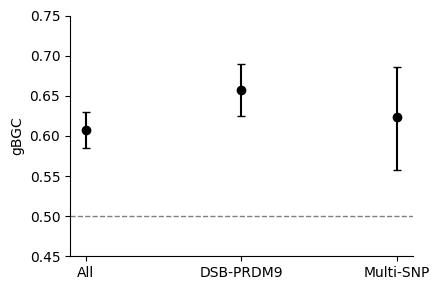

In [6]:
gbgc_plot_df = pl.DataFrame([
    {"class": "All", **sperm_gc},
    {"class": "DSB-PRDM9", **sperm_dsb_gc},
    {"class": "Multi-SNP", **sperm_multi_gc},
])

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.errorbar(
    np.arange(gbgc_plot_df.height),
    gbgc_plot_df["gBGC"],
    yerr=[gbgc_plot_df["gBGC"] - gbgc_plot_df["ci_low"], gbgc_plot_df["ci_high"] - gbgc_plot_df["gBGC"]],
    fmt="o",
    color="black",
    capsize=3,
)
ax.axhline(0.5, color="0.5", ls="--", lw=1)
ax.set_xticks(np.arange(gbgc_plot_df.height), gbgc_plot_df["class"])
ax.set_ylabel("gBGC")
ax.set_ylim(0.45, 0.75)
ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
fig.savefig(figure_dir / "gbgc_sperm_ncos.pdf")

## Relative rates

In [7]:
ydf = (
    all_converted_snps_with_seq_df
    .drop_nulls()
    .filter(pl.col("sample_id").is_in(sperm_ids))
    .with_columns(
        seq_from=pl.when(pl.col("fits1_more") != 1).then(pl.col("refseq_start1")).otherwise(pl.col("refseq_start2")),
        seq_to=pl.when(pl.col("fits1_more") == 1).then(pl.col("refseq_start1")).otherwise(pl.col("refseq_start2")),
    )
    .group_by("seq_from", "seq_to")
    .len()
    .sort("seq_from", "seq_to")
)
yd = {x + y: n for x, y, n in ydf.rows()}

all_snps_df = (
    NCO_df
    .select("sample_id", "chrom", "read_name", "snp_positions_on_read")
    .explode("snp_positions_on_read")
    .rename({"snp_positions_on_read": "start"})
)

def join_all_snps(filename):
    return (
        all_snps_df.lazy()
        .join(
            pl.scan_parquet(filename).select(
                "read_name",
                "start",
                "refseq_start1",
                "refseq_start2",
                "fits1_more",
            ),
            on=["read_name", "start"],
        )
        .collect()
    )

all_snps_with_seq_df = pl.concat(
    joblib.Parallel(n_jobs=-1, verbose=1)(
        joblib.delayed(join_all_snps)(filename) for filename in snp_filenames
    )
)

closest_snp_to_converted_with_seq_df = (
    all_snps_with_seq_df
    .drop_nulls()
    .rename({"start": "other_snp"})
    .join(all_converted_snps_with_seq_df.drop_nulls(), on="read_name")
    .with_columns(diff_to_converted_snp=(pl.col("start") - pl.col("other_snp")).abs())
    .filter(pl.col("diff_to_converted_snp") > 0)
    .sort("read_name", "diff_to_converted_snp")
    .group_by("read_name", maintain_order=True)
    .first()
)

zdf = (
    closest_snp_to_converted_with_seq_df
    .filter(pl.col("sample_id").is_in(sperm_ids))
    .drop_nulls()
    .with_columns(
        seq_from=pl.when(pl.col("fits1_more") != 1).then(pl.col("refseq_start1")).otherwise(pl.col("refseq_start2")),
        seq_to=pl.when(pl.col("fits1_more") == 1).then(pl.col("refseq_start1")).otherwise(pl.col("refseq_start2")),
    )
    .group_by("seq_from", "seq_to")
    .len()
    .sort("seq_from", "seq_to")
)
zd = {x + y: n for x, y, n in zdf.rows()}

counts_at_converted_per_pair = np.array([
    yd["CA"] + yd["GT"],
    yd["GA"] + yd["CT"],
    yd["GC"] + yd["CG"],
    yd["AC"] + yd["TG"],
    yd["AG"] + yd["TC"],
    yd["TA"] + yd["AT"],
])

counts_near_converted_per_pair = np.array([
    zd["CA"] + zd["GT"],
    zd["GA"] + zd["CT"],
    zd["GC"] + zd["CG"],
    zd["AC"] + zd["TG"],
    zd["AG"] + zd["TC"],
    zd["TA"] + zd["AT"],
])

counts_at_converted_per_pair_cis = np.array([
    statsmodels.stats.proportion.proportion_confint(x, np.sum(counts_at_converted_per_pair), method="binom_test")
    for x in counts_at_converted_per_pair
])
counts_near_converted_per_pair_cis = np.array([
    statsmodels.stats.proportion.proportion_confint(x, np.sum(counts_near_converted_per_pair), method="binom_test")
    for x in counts_near_converted_per_pair
])
total_cis = np.array([
    [min([xl / el, xl / eh, xh / el, xh / eh]), max([xl / el, xl / eh, xh / el, xh / eh])]
    for (xl, xh), (el, eh) in zip(counts_at_converted_per_pair_cis, counts_near_converted_per_pair_cis)
])
rel_props = counts_at_converted_per_pair / counts_near_converted_per_pair

pl.DataFrame({
    "class": ["CA/GT", "GA/CT", "GC/CG", "AC/TG", "AG/TC", "TA/AT"],
    "converted": counts_at_converted_per_pair,
    "nearby": counts_near_converted_per_pair,
    "relative": rel_props,
    "ci_low": total_cis[:, 0],
    "ci_high": total_cis[:, 1],
})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/nfs/users/nfs_r/rs42/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 672 tasks      | elapsed:   32.8s
[Parallel(n_jobs=-1)]: Done 1122 tasks      | elapsed:   48.8s
[Parallel(n_jobs=-1)]: Done 1496 out of 1496 | elapsed:  1.2min finished


class,converted,nearby,relative,ci_low,ci_high
str,i64,i64,f64,f64,f64
"""CA/GT""",167,164,1.018293,0.699566,1.25967
"""GA/CT""",545,633,0.860979,0.693275,0.911606
"""GC/CG""",165,169,0.976331,0.672059,1.208183
"""AC/TG""",227,136,1.669118,1.155838,2.051851
"""AG/TC""",876,745,1.175839,0.975469,1.208793
"""TA/AT""",119,91,1.307692,0.822232,1.774112


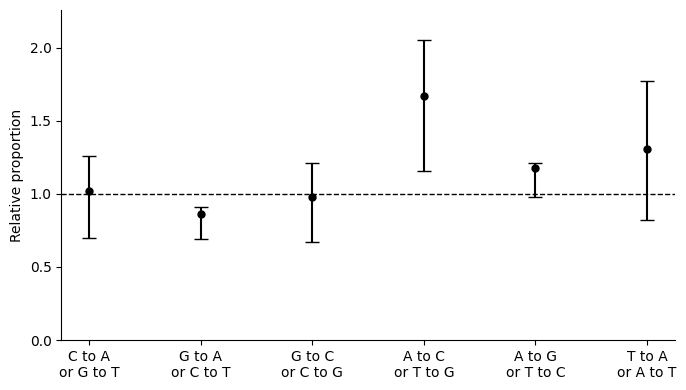

In [8]:
labels = [
    "C to A\nor G to T",
    "G to A\nor C to T",
    "G to C\nor C to G",
    "A to C\nor T to G",
    "A to G\nor T to C",
    "T to A\nor A to T",
]
x = np.arange(len(labels))
yerr = np.array([[h - low, high - h] for h, low, high in zip(rel_props, total_cis[:, 0], total_cis[:, 1])]).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(x=x, y=rel_props, yerr=yerr, fmt="o", color="black", ecolor="black", capsize=5, markersize=5)
ax.axhline(1, color="black", ls="--", lw=1)
ax.set_xticks(x, labels)
ax.set_ylabel("Relative proportion")
ax.set_ylim(0, max(1.15, np.nanmax(rel_props + yerr[1]) * 1.1))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(figure_dir / "gbgc_relative_conversion_rates.pdf")

## Nearest SNP

In [9]:
dist_bins = [[0, 50], [50, 100], [100, 200], [200, 500], [500, 1000], [1000, 10000]]

biases = []
cis = []
for h, l in tqdm.tqdm(dist_bins):
    bin_df = converted_snps_with_seq_df.filter(pl.col("min_snp_diff").is_between(h, l))
    stat = gc_stats(bin_df, sperm_ids)
    biases.append(stat["gBGC"])
    cis.append((stat["ci_low"], stat["ci_high"]))

gbgc_by_distance_df = pl.DataFrame({
    "bin": [f"{h}-{l}" for h, l in dist_bins],
    "gBGC": biases,
    "ci_low": [x[0] for x in cis],
    "ci_high": [x[1] for x in cis],
})

gbgc_by_distance_df

100%|██████████| 6/6 [00:00<00:00,  7.52it/s]


bin,gBGC,ci_low,ci_high
str,f64,f64,f64
"""0-50""",0.577406,0.51257,0.64038
"""50-100""",0.586777,0.522758,0.648982
"""100-200""",0.636656,0.580476,0.688786
"""200-500""",0.581395,0.535964,0.62588
"""500-1000""",0.615854,0.561038,0.667848
"""1000-10000""",0.651639,0.588243,0.709272


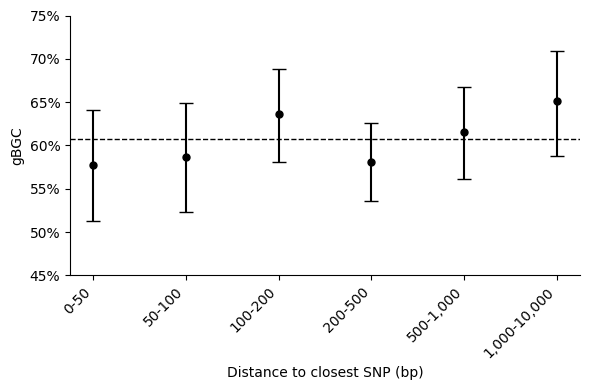

In [10]:
yerr = np.array([[h - low, high - h] for h, (low, high) in zip(biases, cis)]).T
labels = ["0-50", "50-100", "100-200", "200-500", "500-1,000", "1,000-10,000"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(x=x, y=biases, yerr=yerr, fmt="o", color="black", ecolor="black", capsize=5, markersize=5)
ax.axhline(sperm_gc["gBGC"], c="black", ls="--", lw=1)
ax.set_xticks(x, labels, rotation=45, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Distance to closest SNP (bp)")
ax.set_ylabel("gBGC")
ax.set_ylim(0.45, 0.75)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(figure_dir / "gbgc_by_nearest_snp_distance.pdf")

## Summary

In [11]:
key_values = {
    "sperm gBGC": sperm_gc["gBGC"],
    "sperm gBGC CI low": sperm_gc["ci_low"],
    "sperm gBGC CI high": sperm_gc["ci_high"],
    "sperm gBGC n": sperm_gc["n"],
    "sperm gBGC reads": sperm_gc["n_reads"],
    "DSB-PRDM9 NCO gBGC": sperm_dsb_gc["gBGC"],
    "DSB-PRDM9 NCO gBGC CI low": sperm_dsb_gc["ci_low"],
    "DSB-PRDM9 NCO gBGC CI high": sperm_dsb_gc["ci_high"],
    "DSB-PRDM9 NCO gBGC n": sperm_dsb_gc["n"],
    "DSB-PRDM9 NCO gBGC Fisher P": sperm_dsb_gc["fisher_p"],
    "multi-SNP NCO gBGC": sperm_multi_gc["gBGC"],
    "multi-SNP NCO gBGC CI low": sperm_multi_gc["ci_low"],
    "multi-SNP NCO gBGC CI high": sperm_multi_gc["ci_high"],
    "multi-SNP NCO gBGC n": sperm_multi_gc["n"],
}

key_values

{'sperm gBGC': 0.6077134986225895,
 'sperm gBGC CI low': 0.5848626321232496,
 'sperm gBGC CI high': 0.6300484892540437,
 'sperm gBGC n': 1815,
 'sperm gBGC reads': 1692,
 'DSB-PRDM9 NCO gBGC': 0.6575505350772889,
 'DSB-PRDM9 NCO gBGC CI low': 0.6243048146303324,
 'DSB-PRDM9 NCO gBGC CI high': 0.6891278936778733,
 'DSB-PRDM9 NCO gBGC n': 841,
 'DSB-PRDM9 NCO gBGC Fisher P': np.float64(6.222251838143426e-05),
 'multi-SNP NCO gBGC': 0.6238532110091743,
 'multi-SNP NCO gBGC CI low': 0.5574189541283785,
 'multi-SNP NCO gBGC CI high': 0.6860297725629145,
 'multi-SNP NCO gBGC n': 218}